In [10]:
#Import necessary libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [12]:
# prompt: df should read csv directly from yfinance website of live stock data of TATAMOTORS
#Load dataset
! pip install yfinance
import yfinance as yf

df = yf.download('ALLCARGO.BO')


     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
      --------------------------------------- 0.1/3.0 MB 871.5 kB/s eta 0:00:04
      --------------------------------------- 0.1/3.0 MB 871.5 kB/s eta 0:00:04
      --------------------------------------- 0.1/3.0 MB 871.5 kB/s eta 0:00:04
     - -------------------------------------- 0.1/3.0 MB 590.8 kB/s eta 0:00:05
     - -------------------------------------- 0.1/3.0 MB 590.8 kB/s eta 0:00:05
     - -------------------------------------- 0.1/3.0 MB 450.6 kB/s eta 0:00:07
     - -------------------------------------- 0.1/3.0 MB 450.6 kB/s eta 0:00:07
     -- ------------------------------------- 0.2/3.0 MB 399.3 kB/s eta 0:00:08
     -- ------------------------------------- 0.2/3.0 MB 378.3 kB/s eta 0:00:08
     -- ------------------------------------- 0.2/3.0 MB 398.4 kB/s eta 0:00:07
     -- ------------------------------------- 0.2/3.0 MB 3


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed


In [13]:
#Display the first few rows of the dataframe:
print(df.head())


                Open       High       Low     Close  Adj Close     Volume
Date                                                                     
2006-06-23  12.99500  17.225000  12.99500  16.75375   2.438416  152537360
2006-06-26  17.04250  17.078751  14.45000  15.10375   2.198268   43378720
2006-06-27  14.93625  15.100000  14.17625  14.48125   2.107667   22772800
2006-06-28  14.10000  15.487500  13.85000  15.27375   2.223011   42082240
2006-06-29  15.43750  16.625000  15.37500  16.26375   2.367100   44800720


In [14]:
#Preprocessing
#Handling missing values

df = df.dropna()


In [21]:
# Normalize the dataset

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [31]:
type(scaled_data)

numpy.ndarray

In [22]:
#Create trainign dataset

training_data_len = int(np.ceil(len(scaled_data) * 0.8))
train_data = scaled_data[0:int(training_data_len), :]

In [23]:
#Create teh dataset for features and labels

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [24]:
#Model Building

# define the model

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [25]:
#Compile the model

model.compile(optimizer='adam', loss='mean_squared_error')


In [26]:
#Train the model

model.fit(x_train, y_train, batch_size=1, epochs=1)


3540/3540 [==============================] - 64s 17ms/step - loss: 2.7750e-04


In [27]:
# Model Eveluation


#create testing dataset

test_data = scaled_data[training_data_len - 60:, :]
x_test = []
y_test = df['Close'][training_data_len:].values

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [28]:
#get the predictions

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

29/29 [==============================] - 2s 13ms/step


In [29]:
# Evaluate the model

rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f'RMSE: {rmse}')

RMSE: 27.79176120873348


C:\Users\chira\AppData\Local\Temp\ipykernel_320\418121340.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


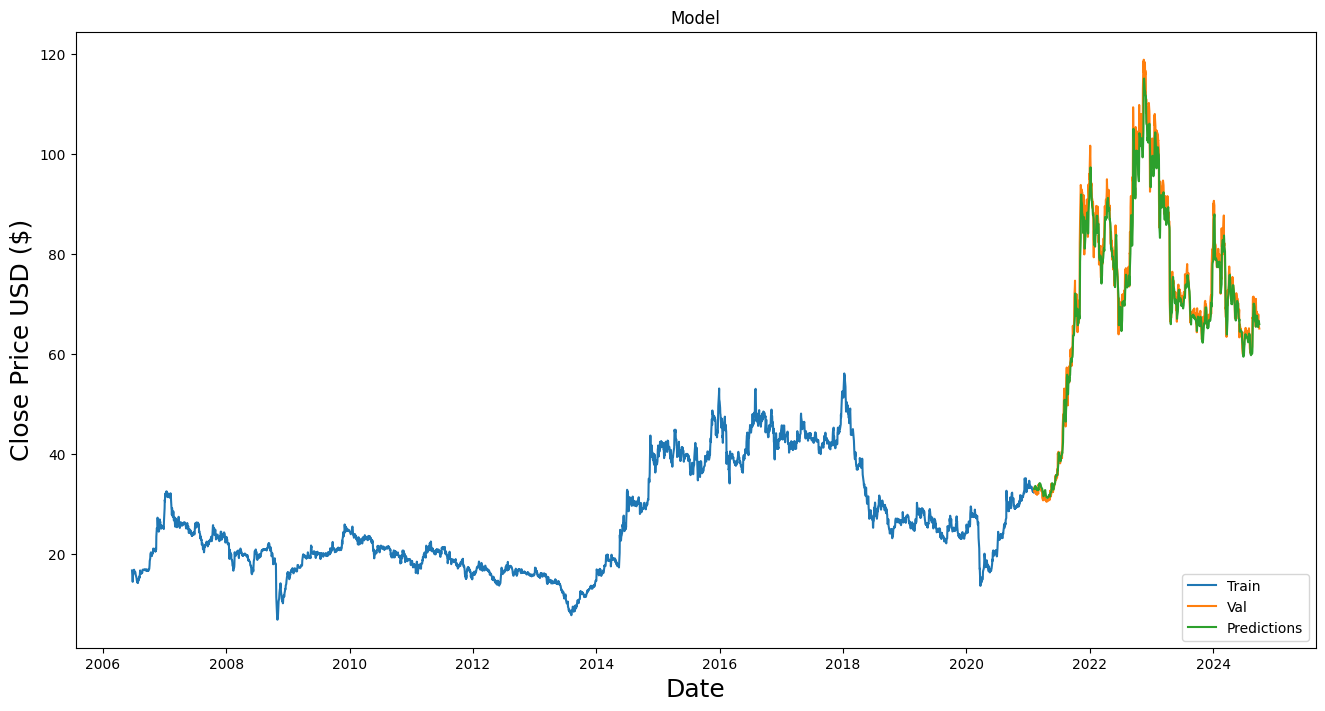

In [30]:
# Plot the results


train = df[:training_data_len]
valid = df[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()
